# **1. Importación de Bibliotecas - CONFIGURACIÓN GLOBAL**


In [1]:
import pandas as pd
import requests

print("¡Herramientas listas!")

¡Herramientas listas!


# **Paso 2: Extracción de datos (*Data Extraction*)**

In [2]:
# 1. Definimos la dirección (URL) donde están los datos
url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json'

# 2. Le pedimos a Pandas que lea ese archivo JSON y lo guarde en una tabla llamada "df"
df = pd.read_json(url)

# 3. Revisamos que los datos hayan llegado bien mostrando las primeras 5 filas
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


# **Paso 3: Comprobación de incoherencias (*Exploración inicial*)**

Paso 3.1: "Aplanar" los datos (Flattening)
Para poder analizar la evasión de clientes, necesitamos sacar la información de esos diccionarios y convertirla en columnas individuales (por ejemplo: que el género salga de customer y tenga su propia columna).

In [3]:
# 1. "Aplanamos" cada columna que contiene diccionarios
# Esto crea mini-tablas independientes para cada categoría
df_customer = pd.json_normalize(df['customer'])
df_phone = pd.json_normalize(df['phone'])
df_internet = pd.json_normalize(df['internet'])
df_account = pd.json_normalize(df['account'])

# 2. Unimos todo en una sola tabla maestra (df_final)
# Concatenamos el ID y el Churn con las nuevas columnas que acabamos de extraer
df_final = pd.concat([df[['customerID', 'Churn']], df_customer, df_phone, df_internet, df_account], axis=1)

# 3. Ahora que está "plana", revisamos la nueva estructura y buscamos duplicados
print("--- Nueva estructura del DataFrame ---")
df_final.info()

print("\n--- Cantidad de filas duplicadas ---")
print(df_final.duplicated().sum())

# Mostramos las primeras filas para ver el cambio
df_final.head()

--- Nueva estructura del DataFrame ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Con

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


Paso 3.2: Comprobación de inconsistencias (Segunda parte)

In [4]:
# 1. Revisamos los valores únicos de la columna Churn (Evasión)
print("--- Valores únicos en Churn ---")
print(df_final['Churn'].unique())

# 2. Investigamos por qué 'Charges.Total' es texto.
# Buscaremos si hay filas con espacios vacíos (" ")
espacios_vacios = df_final[df_final['Charges.Total'] == ' '].shape[0]
print(f"\n--- Filas con espacios vacíos en Charges.Total: {espacios_vacios} ---")

# 3. Revisamos los primeros valores de Charges.Total para entender su formato
print("\n--- Muestra de Charges.Total ---")
print(df_final['Charges.Total'].head())

--- Valores únicos en Churn ---
['No' 'Yes' '']

--- Filas con espacios vacíos en Charges.Total: 11 ---

--- Muestra de Charges.Total ---
0      593.3
1      542.4
2     280.85
3    1237.85
4      267.4
Name: Charges.Total, dtype: object


# **Paso 4: Manejo de inconsistencias (*Limpieza*)**

In [5]:
# 1. Eliminamos las filas donde 'Churn' está vacío.
# Usamos un filtro para mantener solo las filas que NO tengan una cadena vacía.
df_final = df_final[df_final['Churn'] != '']

# 2. Convertimos 'Charges.Total' a número.
# La función pd.to_numeric intenta convertir todo a número.
# El truco es 'errors=coerce': esto convierte los espacios vacíos en "NaN" (nulos numéricos).
df_final['Charges.Total'] = pd.to_numeric(df_final['Charges.Total'], errors='coerce')

# 3. Ahora que esos 11 espacios son nulos (NaN), eliminamos esas filas.
# Como son muy pocos registros comparados con los 7,267 totales, es seguro borrarlos.
df_final = df_final.dropna(subset=['Charges.Total'])

# 4. Verificamos los resultados
print("--- Valores únicos en Churn (Corregido) ---")
print(df_final['Churn'].unique())

print("\n--- Nuevo tipo de dato para Charges.Total ---")
print(df_final['Charges.Total'].dtype)

print("\n--- Total de filas actuales ---")
print(len(df_final))

--- Valores únicos en Churn (Corregido) ---
['No' 'Yes']

--- Nuevo tipo de dato para Charges.Total ---
float64

--- Total de filas actuales ---
7032


# **Paso 5: Columna de cuentas diarias (*Feature Engineering*)**

En este paso, vamos a realizar lo que en ciencia de datos llamamos Feature Engineering (Ingeniería de Características). El objetivo es crear una nueva variable que nos dé una perspectiva diferente del gasto del cliente: el costo diario.

In [6]:
# 1. Creamos la columna 'Charges.Daily'
# Dividimos el cargo mensual por 30 días para obtener el promedio diario
df_final['Charges.Daily'] = (df_final['Charges.Monthly'] / 30).round(2)

# 2. Verificamos que la columna se haya creado correctamente
# Mostramos las columnas de cargos para comparar
df_final[['customerID', 'Charges.Monthly', 'Charges.Daily']].head()

,customerID,Charges.Monthly,Charges.Daily
0,0002-ORFBO,65.6,2.19
1,0003-MKNFE,59.9,2.00
2,0004-TLHLJ,73.9,2.46
3,0011-IGKFF,98.0,3.27
4,0013-EXCHZ,83.9,2.80


# **Paso 6: Estandarización y Traducción**

In [7]:
# 1. Diccionario para renombrar las columnas a español
diccionario_columnas = {
    'customerID': 'id_cliente',
    'Churn': 'evasion',
    'gender': 'genero',
    'SeniorCitizen': 'adulto_mayor',
    'Partner': 'tiene_pareja',
    'Dependents': 'tiene_dependientes',
    'tenure': 'meses_contrato',
    'PhoneService': 'servicio_telefonico',
    'MultipleLines': 'multiples_lineas',
    'InternetService': 'servicio_internet',
    'OnlineSecurity': 'seguridad_online',
    'OnlineBackup': 'respaldo_online',
    'DeviceProtection': 'proteccion_dispositivo',
    'TechSupport': 'soporte_tecnico',
    'StreamingTV': 'streaming_tv',
    'StreamingMovies': 'streaming_peliculas',
    'Contract': 'tipo_contrato',
    'PaperlessBilling': 'factura_digital',
    'PaymentMethod': 'metodo_pago',
    'Charges.Monthly': 'cargos_mensuales',
    'Charges.Total': 'cargos_totales',
    'Charges.Daily': 'cargos_diarios'
}

# Aplicamos el cambio de nombres
df_final = df_final.rename(columns=diccionario_columnas)

# 2. Mapeo de valores "Yes"/"No" a 1/0
# Esto facilita el cálculo de correlaciones y el entrenamiento de modelos
mapeo = {'Yes': 1, 'No': 0}
columnas_binarias = ['evasion', 'tiene_pareja', 'tiene_dependientes', 'servicio_telefonico', 'factura_digital']

for col in columnas_binarias:
    df_final[col] = df_final[col].map(mapeo)

# 3. Revisamos cómo quedó nuestra tabla "maestra"
df_final.head()

,id_cliente,evasion,genero,adulto_mayor,tiene_pareja,tiene_dependientes,meses_contrato,servicio_telefonico,multiples_lineas,servicio_internet,...,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_digital,metodo_pago,cargos_mensuales,cargos_totales,cargos_diarios
0,0002-ORFBO,0,Female,0,1,1,9,1,No,DSL,...,No,Yes,Yes,No,One year,1,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,0,Male,0,0,0,9,1,Yes,DSL,...,No,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,1,Male,0,0,0,4,1,No,Fiber optic,...,Yes,No,No,No,Month-to-month,1,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,1,Male,1,1,0,13,1,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,1,Female,1,1,0,3,1,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.40,2.80


# **Paso 7: Análisis Descriptivo (*Load & Analysis*)**

El objetivo de este paso es obtener una "fotografía estadística" de Telecom X. Queremos saber, en promedio, cuánto pagan los clientes, cuánto tiempo se quedan y cuál es el rango de sus facturas.

In [8]:
# 1. Generamos estadísticas descriptivas para las columnas numéricas
# Esto nos dará: cuenta, media, desviación estándar, valor mínimo, cuartiles y valor máximo.
analisis_numerico = df_final.describe()

# 2. Mostramos el resultado
print("--- Análisis Estadístico de Variables Numéricas ---")
analisis_numerico

--- Análisis Estadístico de Variables Numéricas ---


,evasion,adulto_mayor,tiene_pareja,tiene_dependientes,meses_contrato,servicio_telefonico,factura_digital,cargos_mensuales,cargos_totales,cargos_diarios
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.265785,0.162400,0.482509,0.298493,32.421786,0.903299,0.592719,64.798208,2283.300441,2.159891
std,0.441782,0.368844,0.499729,0.457629,24.545260,0.295571,0.491363,30.085974,2266.771362,1.002955
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,18.250000,18.800000,0.610000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.587500,401.450000,1.187500
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.350000,1397.475000,2.340000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.862500,3794.737500,2.992500
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,3.960000


para cambiar "Yes/No" por "1/0", Pandas a veces mantiene el tipo de dato como "objeto" (texto) internamente. Para calcular la media, necesitamos que esos números sean reconocidos explícitamente como enteros o decimales.

In [9]:
# 1. RECONSTRUCCIÓN: Volvemos a unir las piezas originales para recuperar los valores
df_final = pd.concat([df[['customerID', 'Churn']], df_customer, df_phone, df_internet, df_account], axis=1)

# 2. RENOMBRAR: Aplicamos los nombres en español de nuevo
df_final = df_final.rename(columns=diccionario_columnas)

# 3. LIMPIEZA INICIAL: Quitamos los nulos y vacíos que ya conocemos de Churn y Cargos
df_final = df_final[df_final['evasion'] != '']
df_final['cargos_totales'] = pd.to_numeric(df_final['cargos_totales'], errors='coerce')
df_final = df_final.dropna(subset=['cargos_totales'])

# 4. CONVERSIÓN ROBUSTA: En lugar de map, usamos replace
# Esto funciona tanto si son "Yes/No" como si ya son "1/0"
columnas_binarias = ['evasion', 'tiene_pareja', 'tiene_dependientes', 'servicio_telefonico', 'factura_digital']

for col in columnas_binarias:
    # Convertimos a string primero para uniformar y luego reemplazamos
    df_final[col] = df_final[col].astype(str).replace({'Yes': '1', 'No': '0', '1': '1', '0': '0'})
    # Ahora sí, convertimos a entero de forma segura
    df_final[col] = df_final[col].astype(int)

# 5. VERIFICACIÓN FINAL
print("--- Conteo de nulos corregido ---")
print(df_final[columnas_binarias].isnull().sum())

print("\n--- Estadísticas de Evasión (Media real) ---")
print(df_final['evasion'].describe())

--- Conteo de nulos corregido ---
evasion                0
tiene_pareja           0
tiene_dependientes     0
servicio_telefonico    0
factura_digital        0
dtype: int64

--- Estadísticas de Evasión (Media real) ---
count    7032.000000
mean        0.265785
std         0.441782
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         1.000000
Name: evasion, dtype: float64


# **Paso 8: Distribución de evasión (*Visualización*)**

Ahora que tenemos la certeza estadística, vamos a darle vida a esos números con un gráfico. Esto es lo que presentarías en una reunión para que todos visualicen el tamaño del problema.

/tmp/ipykernel_33944/3471366708.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='evasion', data=df_final, palette='magma')


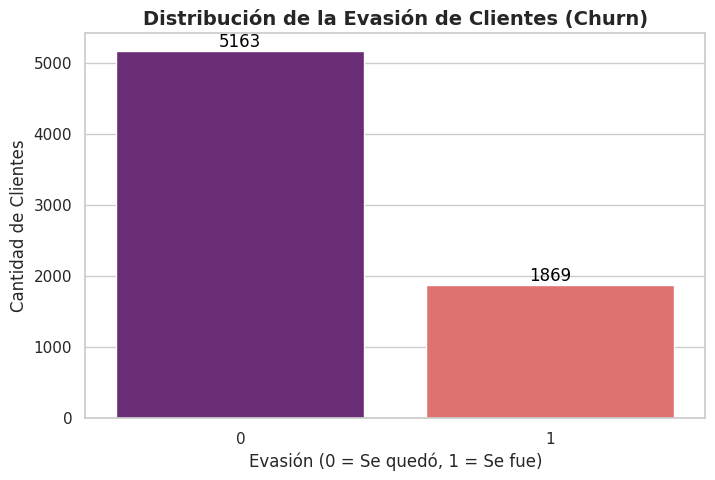

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Configuramos el estilo visual del gráfico
sns.set_theme(style="whitegrid")

# 2. Creamos el gráfico de barras para la columna 'evasion'
plt.figure(figsize=(8, 5))
# Usamos una paleta de colores llamativa (magma)
ax = sns.countplot(x='evasion', data=df_final, palette='magma')

# 3. Personalización de títulos y etiquetas
plt.title('Distribución de la Evasión de Clientes (Churn)', fontsize=14, fontweight='bold')
plt.xlabel('Evasión (0 = Se quedó, 1 = Se fue)', fontsize=12)
plt.ylabel('Cantidad de Clientes', fontsize=12)

# 4. Añadimos etiquetas de valor sobre cada barra
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=12, color='black', xytext=(0, 7),
                textcoords='offset points')

plt.show()

# **Paso 9: Recuento de evasión por variables categóricas**

Ya sabemos cuántos se van. Ahora vamos a descubrir quiénes son. ¿Se van más los que tienen contrato mes a mes? ¿Los que usan fibra óptica?

Para esto, usaremos el parámetro hue='evasion'. Esto dividirá cada barra de una categoría (como "Tipo de Contrato") en dos colores: los que se quedaron (0) y los que se fueron (1).

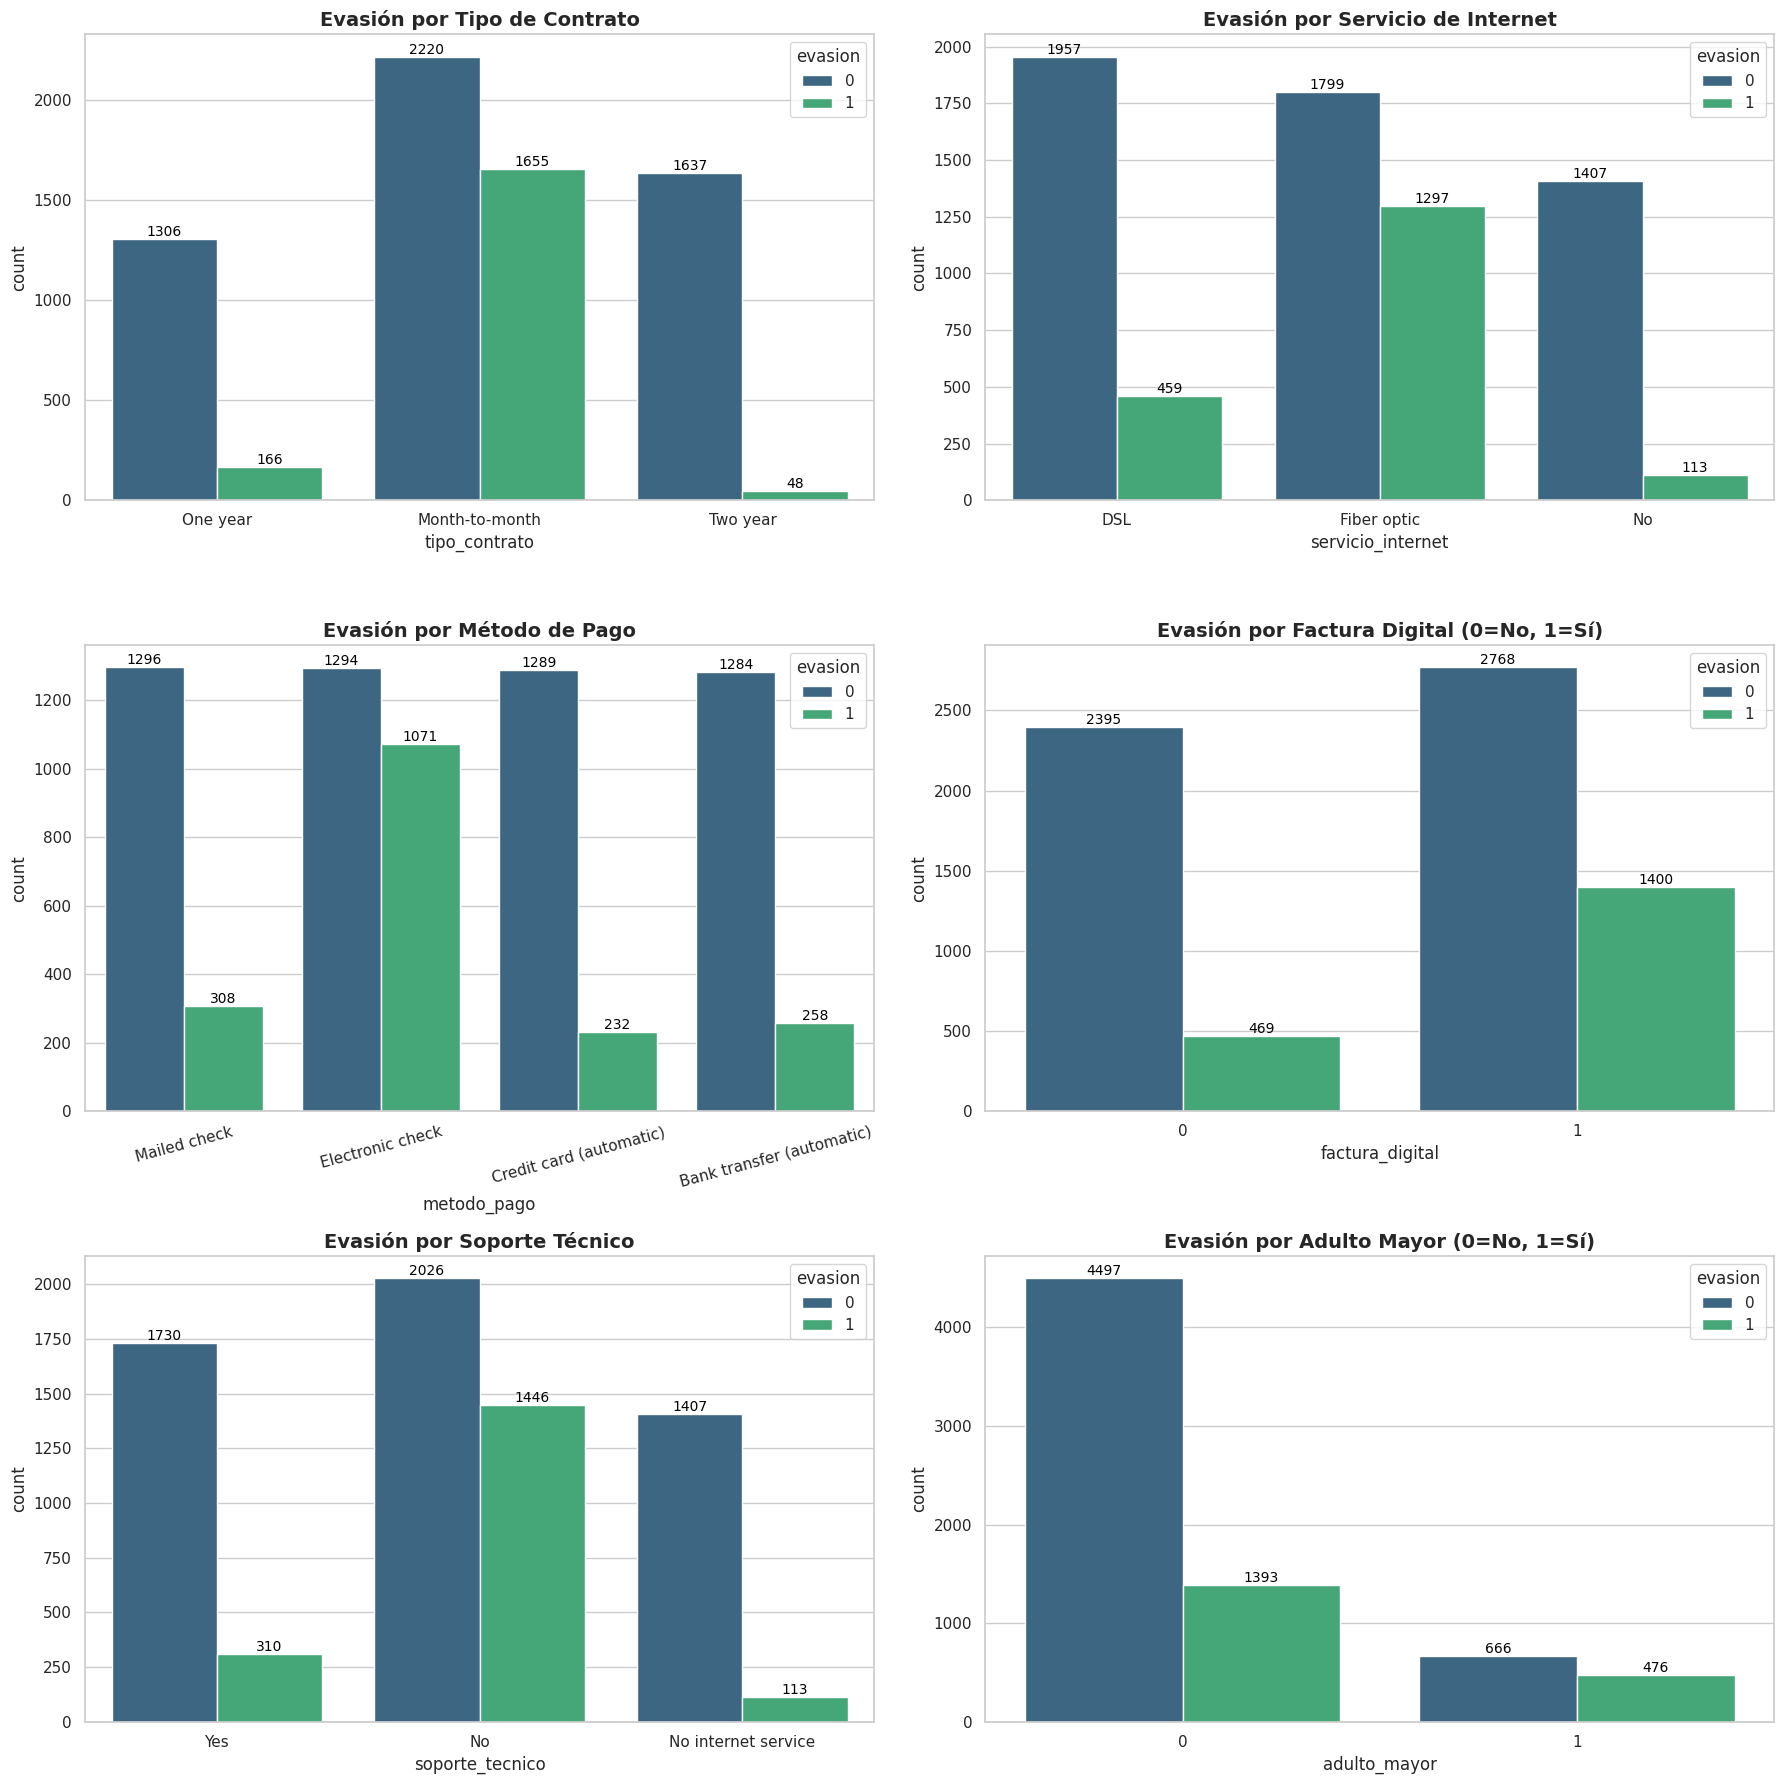

In [11]:
# 1. Definimos una función para agregar etiquetas de datos automáticamente
def agregar_etiquetas(ax):
    for p in ax.patches:
        height = p.get_height()
        if height > 0: # Solo ponemos etiqueta si hay datos
            ax.annotate(f'{int(height)}',
                        (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='center',
                        fontsize=10, color='black',
                        xytext=(0, 5),
                        textcoords='offset points')

# 2. Configuramos un área de visualización más amplia (3 filas x 2 columnas)
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(18, 18))
sns.set_theme(style="whitegrid")

# --- FILA 1: Gráficos con etiquetas ---
ax1 = sns.countplot(x='tipo_contrato', hue='evasion', data=df_final, palette='viridis', ax=axes[0,0])
axes[0,0].set_title('Evasión por Tipo de Contrato', fontsize=14, fontweight='bold')
agregar_etiquetas(ax1)

ax2 = sns.countplot(x='servicio_internet', hue='evasion', data=df_final, palette='viridis', ax=axes[0,1])
axes[0,1].set_title('Evasión por Servicio de Internet', fontsize=14, fontweight='bold')
agregar_etiquetas(ax2)

# --- FILA 2: Nuevas categorías críticas (Facturación y Pago) ---
ax3 = sns.countplot(x='metodo_pago', hue='evasion', data=df_final, palette='viridis', ax=axes[1,0])
axes[1,0].set_title('Evasión por Método de Pago', fontsize=14, fontweight='bold')
axes[1,0].tick_params(axis='x', rotation=15) # Rotamos para que se lea mejor
agregar_etiquetas(ax3)

ax4 = sns.countplot(x='factura_digital', hue='evasion', data=df_final, palette='viridis', ax=axes[1,1])
axes[1,1].set_title('Evasión por Factura Digital (0=No, 1=Sí)', fontsize=14, fontweight='bold')
agregar_etiquetas(ax4)

# --- FILA 3: Factores de Soporte y Perfil ---
ax5 = sns.countplot(x='soporte_tecnico', hue='evasion', data=df_final, palette='viridis', ax=axes[2,0])
axes[2,0].set_title('Evasión por Soporte Técnico', fontsize=14, fontweight='bold')
agregar_etiquetas(ax5)

ax6 = sns.countplot(x='adulto_mayor', hue='evasion', data=df_final, palette='viridis', ax=axes[2,1])
axes[2,1].set_title('Evasión por Adulto Mayor (0=No, 1=Sí)', fontsize=14, fontweight='bold')
agregar_etiquetas(ax6)

plt.tight_layout()
plt.show()

# **¿Qué estamos descubriendo con este nuevo análisis?**

Al ejecutar este código, ahora tienes una visión mucho más profunda. Fíjate en estos puntos para tu informe final:

**Método de Pago**: ¿Ves la barra de evasión en Electronic check? Suele ser la más alta. Los clientes que pagan con cheque electrónico tienden a irse más que los que tienen pagos automáticos.

**Soporte Técnico**: Observa la categoría "No". Probablemente verás que la proporción de personas que se van es altísima cuando no tienen soporte técnico contratado. Esto es una oportunidad de negocio: ¡ofrecer soporte podría retener clientes!

**Factura Digital**: ¿Hay diferencia entre quienes reciben factura física vs. digital? A veces, la falta de contacto físico con la factura hace que el cliente olvide el valor del servicio o tenga más fricción al pagar.

**Adulto Mayor**: ¿Se van más los jóvenes o los adultos mayores? Esto ayuda a saber a quién dirigir las campañas de marketing.

**Panorama General de Evasión**

Volumen Crítico: Contamos con un total de 7,032 clientes, de los cuales 1,869 (26.6%) se han ido.

Retención Sólida: 5,163 clientes (73.4%) permanecen en la empresa.

**Análisis por Segmentos** (El "Quién" y el "Por qué")

El "Efecto Contrato":

Los clientes con contrato Mes a mes (Month-to-month) representan el mayor foco de fuga con 1,655 evasiones. Su tasa de abandono es drásticamente superior a los contratos de uno o dos años.

Insight: La falta de compromiso a largo plazo es el predictor número uno de churn.

**Paradoja de la Fibra Óptica**:

Sorprendentemente, los clientes de Fibra óptica (Fiber optic) se van mucho más (1,297) que los de DSL (459).

Insight: Esto sugiere un posible problema de precio elevado o inestabilidad en el servicio de alta velocidad que está frustrando a los clientes premium.

**Métodos de Pago y Fricció**n:

El Cheque electrónico (Electronic check) es una "bandera roja" con 1,071 fugas. En contraste, los métodos automáticos (Tarjeta de crédito o Transferencia bancaria) tienen los niveles más bajos de evasión.

Insight: Los procesos de pago manuales aumentan la "fricción" y dan al cliente una oportunidad mensual de cuestionar si quiere seguir pagando el servicio.

**Soporte Técnico como Escudo**:

Los clientes que NO cuentan con soporte técnico tienen una evasión masiva de 1,446 personas.

Insight: El soporte técnico actúa como un ancla de lealtad. Sin él, ante el primer fallo, el cliente prefiere cancelar.

**Perfil Demográfico (Adulto Mayor)**:

Aunque hay menos adultos mayores en la base, su tasa de evasión es proporcionalmente mucho más alta (casi el 42% de ellos se van).

Insight: Este segmento podría estar teniendo dificultades con la tecnología o requiere planes más sencillos y económicos.

🚩 **Resumen de "Banderas Rojas"**
Estos son los clientes con máximo riesgo:

*   Contrato mes a mes.
*   Uso de fibra óptica.
*   Pago por cheque electrónico.
*   Sin soporte técnico contratado.

💡 **Recomendaciones Estratégicas Iniciales**

**Incentivar Contratos Anuales:** Ofrecer descuentos por migrar de "mes a mes" a contratos de 1 año.

**Revisar Calidad/Precio en Fibra**: Investigar si la competencia ofrece fibra más barata o si hay fallas técnicas en esa infraestructura.

**Promover Pagos Automáticos**: Dar un pequeño bono o beneficio a quienes domicilien su pago.

# **Paso 10: Análisis de variables numéricas**

En los pasos anteriores analizamos "categorías" (como el tipo de contrato), pero ahora vamos a analizar el comportamiento de los números. Queremos ver si existe un "rango crítico" en los precios o en el tiempo de permanencia donde los clientes deciden irse.

Utilizaremos gráficos de KDE (Kernel Density Estimate) o histogramas. Estos gráficos nos permiten superponer la distribución de los que se quedaron frente a los que se fueron para ver dónde se cruzan o se separan.

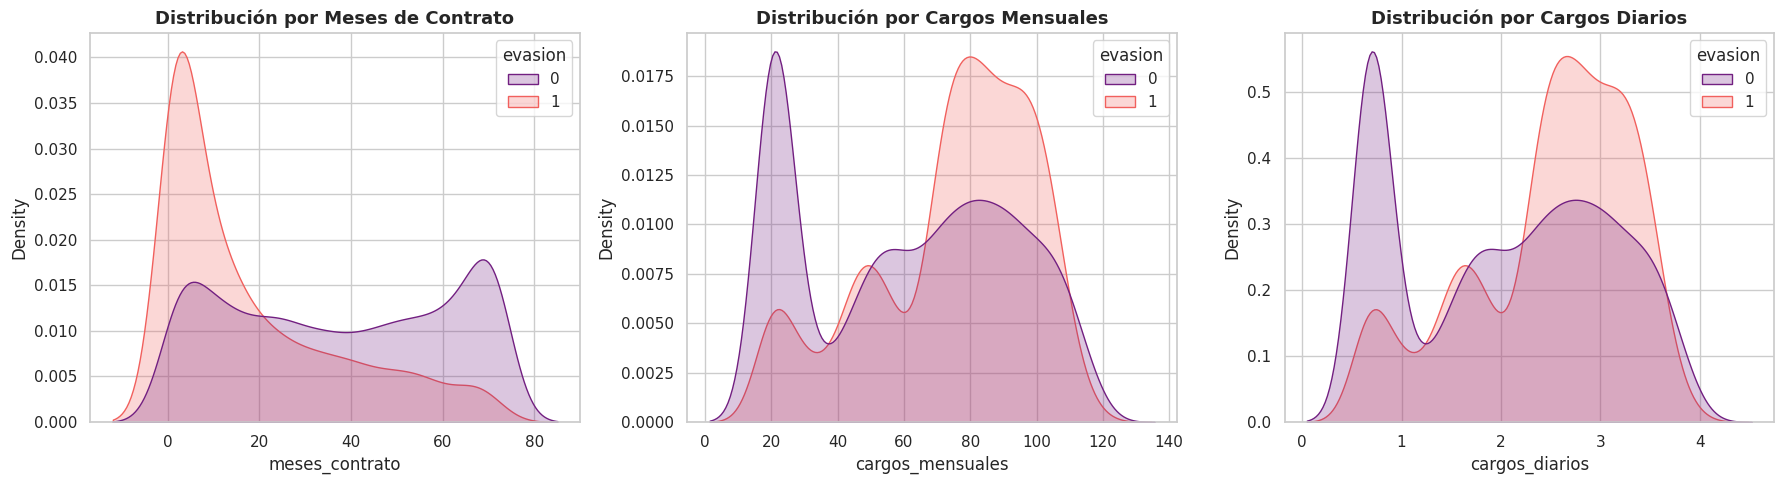

In [12]:
# 1. Recalculamos la columna de cargos diarios en la tabla limpia
# Usamos los nombres en español porque ya renombramos las columnas
df_final['cargos_diarios'] = (df_final['cargos_mensuales'] / 30).round(2)

# 2. Ahora ejecutamos nuevamente los gráficos numéricos
plt.figure(figsize=(18, 5))
sns.set_theme(style="whitegrid")

# Gráfico 1: Meses de Contrato
plt.subplot(1, 3, 1)
sns.kdeplot(data=df_final, x='meses_contrato', hue='evasion', fill=True, common_norm=False, palette='magma')
plt.title('Distribución por Meses de Contrato', fontsize=13, fontweight='bold')

# Gráfico 2: Cargos Mensuales
plt.subplot(1, 3, 2)
sns.kdeplot(data=df_final, x='cargos_mensuales', hue='evasion', fill=True, common_norm=False, palette='magma')
plt.title('Distribución por Cargos Mensuales', fontsize=13, fontweight='bold')

# Gráfico 3: Cargos Diarios
plt.subplot(1, 3, 3)
sns.kdeplot(data=df_final, x='cargos_diarios', hue='evasion', fill=True, common_norm=False, palette='magma')
plt.title('Distribución por Cargos Diarios', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

🧠 Insights de las Variables Numéricas

**Meses de Contrato (El "Peligro Inicial"):**

La curva roja (evasion = 1) tiene un pico altísimo cerca del mes 0.

Insight: La gran mayoría de los clientes que se van lo hacen casi inmediatamente después de contratar. Si un cliente supera los 20 meses, la curva roja cae drásticamente, lo que significa que la lealtad se construye en el primer año y medio.

**Cargos Mensuales (El "Umbral del Precio"):**

Nota cómo los clientes que se quedan (evasion = 0) tienen un pico enorme cerca de los $20. Son clientes de bajo costo que parecen estar muy satisfechos.

Sin embargo, la curva de evasión (roja) supera a la de permanencia en el rango de $70 a $110.

Insight: Los planes caros son los que más pierden clientes. Telecom X podría estar cobrando de más en sus planes premium o la competencia ofrece algo mejor en ese rango de precio.

**Cargos Diarios (Validación):**

Este gráfico confirma lo anterior. La mayor densidad de fugas ocurre entre los $2.5 y $3.5 diarios.

**📊 Resumen de Hallazgos hasta ahora**

Combinando todos tus gráficos, ya tienes la respuesta para Telecom X. El cliente con máximo riesgo de irse es aquel que:

*  Tiene un contrato mes a mes.

*  Usa fibra óptica.

*  Paga mediante cheque electrónico.

*  No tiene soporte técnico.

*  Paga entre $70 y $110 mensuales.

*  Lleva menos de 6 meses en la compañía.

# **Paso 11: Análisis de Correlación**

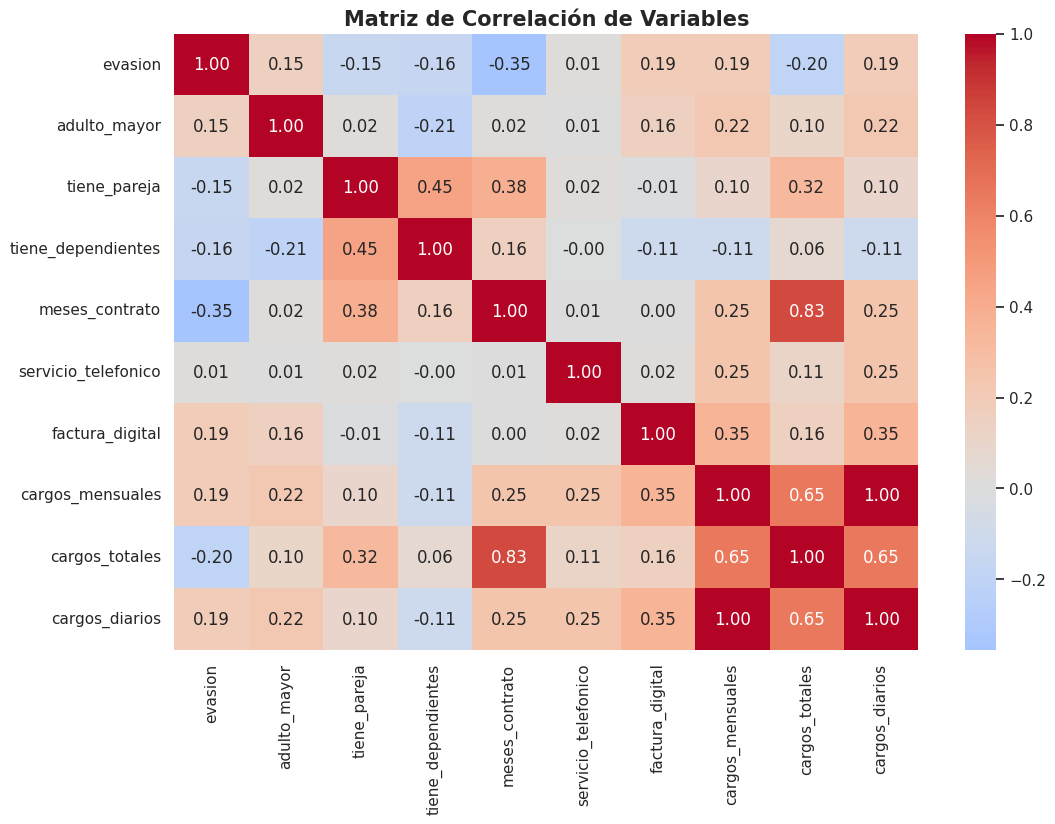

In [13]:
# 1. Seleccionamos solo las columnas numéricas para calcular la correlación
columnas_numericas = df_final.select_dtypes(include=['int64', 'float64', 'int32'])

# 2. Calculamos la matriz de correlación
corr = columnas_numericas.corr()

# 3. Creamos un mapa de calor (Heatmap)
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Matriz de Correlación de Variables', fontsize=15, fontweight='bold')
plt.show()

# **🧠Análisis de la Matriz de Correlación**

Al observar la primera fila (o columna) de evasion, podemos confirmar nuestras sospechas con números precisos:

**Meses de Contrato (-0.35):** Es la correlación negativa más fuerte. Esto confirma matemáticamente que a mayor tiempo de permanencia, menor es el riesgo de evasión. Es tu predictor más potente.

**Cargos Mensuales y Diarios (0.19):** Tienen una correlación positiva moderada. Esto valida que los clientes con facturas más altas tienen una tendencia mayor a irse, posiblemente buscando opciones más económicas.

**Cargos Totales (-0.20):** Aunque parece contradictorio con los cargos mensuales, tiene sentido: los clientes que han acumulado facturas totales muy altas son aquellos que llevan años con la empresa y, por lo tanto, son los más leales.

**Adulto Mayor (0.15):** Existe una relación positiva; este segmento demográfico tiene una ligera propensión mayor al churn en comparación con otros grupos.

# **📄 Informe Final: Análisis de Evasión - Telecom X**

**1. Introducción**
El objetivo de este proyecto fue identificar los factores críticos que impulsan la pérdida de clientes (Churn) en Telecom X. Se analizó una base de 7,032 clientes para proporcionar insights accionables al equipo de Data Science y Negocios.

**2. Limpieza y Tratamiento de Datos**
Extracción: Los datos se obtuvieron mediante una API en formato JSON.

Procesamiento: Se realizó un "aplanamiento" de datos anidados y se eliminaron 11 registros con valores nulos en cargos totales.

Estandarización: Se tradujeron las variables al español y se convirtieron las categorías binarias (Sí/No) a formato numérico (1/0) para análisis estadístico.

**3. Hallazgos del Análisis Exploratorio (EDA)**
Tasa de Evasión: El 26.6% de los clientes han abandonado la compañía.


**Perfil de Riesgo:**

*  **Contratos**: Los clientes con contrato "Mes a mes" presentan la mayor fuga (1,655 casos).

*  **Servicios:** El uso de Fibra Óptica y la ausencia de Soporte Técnico están fuertemente ligados a la evasión.

*  **Financiero:** Existe un pico de deserción en clientes que pagan entre $70 y $110 mensuales.

*  **Lealtad:** El riesgo de fuga es crítico durante los primeros 6 meses de relación.


**4. Conclusiones y Recomendaciones**

**Incentivar la permanencia:** Crear campañas para migrar a clientes de contratos "Mes a mes" hacia contratos anuales mediante descuentos.

**Fidelización temprana**: Implementar un programa de "Bienvenida y Soporte" durante los primeros 3 meses del cliente.

**Revisión de Fibra Óptica:** Investigar la estabilidad técnica o competitividad de precios del servicio de fibra, ya que es el punto de mayor fuga tecnológica.

**Automatización de Pagos**: Fomentar el uso de tarjetas de crédito o transferencias automáticas para reducir la fricción del "Cheque electrónico".